1. Create a Python program to manage employee records. Store employee IDs and names using tuples, salaries using dictionaries, and provide functions to add, search, and display employee information.

In [7]:
# Data structures to store employee information
employees = [] # List of tuples: (employee_id, name)
salaries = {} # Dictionary: {employee_id: salary}

def add_employee(employee_id, name, salary):
    """Adds a new employee to the records."""
    # Check if employee_id already exists
    for emp_id, _ in employees:
        if emp_id == employee_id:
            print(f"Error: Employee with ID {employee_id} already exists.")
            return

    employees.append((employee_id, name))
    salaries[employee_id] = salary
    print(f"Employee {name} (ID: {employee_id}) added successfully.")

def search_employee(employee_id):
    """Searches for an employee by ID and displays their information."""
    found = False
    for emp_id, name in employees:
        if emp_id == employee_id:
            emp_salary = salaries.get(employee_id, 'N/A')
            print(f"Employee Found: ")
            print(f"  ID: {emp_id}")
            print(f"  Name: {name}")
            print(f"  Salary: ${emp_salary:,.2f}")
            found = True
            break
    if not found:
        print(f"Employee with ID {employee_id} not found.")

def display_all_employees():
    """Displays information for all employees."""
    if not employees:
        print("No employee records to display.")
        return

    print("\n--- All Employee Records ---")
    for emp_id, name in employees:
        emp_salary = salaries.get(emp_id, 'N/A')
        print(f"ID: {emp_id}, Name: {name}, Salary: ${emp_salary:,.2f}")
    print("----------------------------")

# Add some employees
add_employee(101, "Alice Smith", 60000)
add_employee(102, "Bob Johnson", 75000)
add_employee(103, "Charlie Brown", 50000)
add_employee(101, "Alice Smith", 60000) # Attempt to add duplicate ID

# Display all employees
display_all_employees()

# Search for an employee
search_employee(102)
search_employee(104) # Search for a non-existent employee

Employee Alice Smith (ID: 101) added successfully.
Employee Bob Johnson (ID: 102) added successfully.
Employee Charlie Brown (ID: 103) added successfully.
Error: Employee with ID 101 already exists.

--- All Employee Records ---
ID: 101, Name: Alice Smith, Salary: $60,000.00
ID: 102, Name: Bob Johnson, Salary: $75,000.00
ID: 103, Name: Charlie Brown, Salary: $50,000.00
----------------------------
Employee Found: 
  ID: 102
  Name: Bob Johnson
  Salary: $75,000.00
Employee with ID 104 not found.


2. Create a program that stores student marks in a dictionary. Calculate average marks, identify toppers, assign grades, and display a performance report.

In [9]:
import collections

# 1. Store student marks in a dictionary
# Structure: {student_name: {subject1: mark1, subject2: mark2, ...}}
student_marks = {
    "Alice": {"Math": 85, "Science": 90, "English": 78},
    "Bob": {"Math": 70, "Science": 65, "English": 72},
    "Charlie": {"Math": 92, "Science": 88, "English": 95},
    "Diana": {"Math": 60, "Science": 75, "English": 80},
    "Eve": {"Math": 95, "Science": 92, "English": 98}
}

def calculate_average_marks(marks_dict):
    """Calculates the average marks for each student."""
    average_marks = {}
    for student, subjects in marks_dict.items():
        if subjects:
            total_marks = sum(subjects.values())
            num_subjects = len(subjects)
            average_marks[student] = total_marks / num_subjects
        else:
            average_marks[student] = 0.0 # No subjects, average is 0
    return average_marks

def assign_grade(average_score):
    """Assigns a grade based on the average score."""
    if average_score >= 90:
        return "A"
    elif average_score >= 80:
        return "B"
    elif average_score >= 70:
        return "C"
    elif average_score >= 60:
        return "D"
    else:
        return "F"

def identify_toppers(average_marks_dict, top_n=1):
    """Identifies the top N students based on their average marks,
    handling ties for the Nth position."""
    if not average_marks_dict:
        return []

    sorted_students = sorted(average_marks_dict.items(), key=lambda item: item[1], reverse=True)

    if not sorted_students:
        return []

    toppers = []
    # Add the first top_n students
    for i in range(min(top_n, len(sorted_students))):
        toppers.append(sorted_students[i])

    # If there are more students and we have at least top_n students in sorted_students,
    # check for ties at the top_n-th position.
    if len(sorted_students) > top_n:
        nth_score = sorted_students[top_n - 1][1]
        # Iterate from the (top_n)th student onwards to find ties
        for i in range(top_n, len(sorted_students)):
            if sorted_students[i][1] == nth_score:
                toppers.append(sorted_students[i])
            else:
                break # Scores are strictly decreasing, so no more ties for this score

    return toppers

def display_performance_report(student_marks_dict):
    """Displays a comprehensive performance report for all students."""
    print("\n--- Student Performance Report ---")

    average_scores = calculate_average_marks(student_marks_dict)

    # Sort students by their names for consistent display
    sorted_students = sorted(average_scores.keys())

    for student in sorted_students:
        print(f"\nStudent: {student}")
        print("  Marks:")
        for subject, mark in student_marks_dict[student].items():
            print(f"    {subject}: {mark}")

        avg_score = average_scores[student]
        grade = assign_grade(avg_score)
        print(f"  Average Score: {avg_score:.2f}")
        print(f"  Grade: {grade}")

    print("\n--- Toppers (Top 1) ---")
    toppers = identify_toppers(average_scores, top_n=1) # Get top 1 topper
    if toppers:
        for student, score in toppers:
            print(f"  {student} (Average: {score:.2f})")
    else:
        print("  No toppers found.")
    print("----------------------------------")

# --- Example Usage ---

# 1. Display initial performance report
display_performance_report(student_marks)

# 2. Add a new student
print("\n--- Adding a new student ---")
student_marks["Frank"] = {"Math": 88, "Science": 82, "English": 79}
display_performance_report(student_marks)

# 3. Update marks for an existing student
print("\n--- Updating marks for Alice ---")
student_marks["Alice"]["Math"] = 90
display_performance_report(student_marks)

# 4. Identify top 2 toppers
print("\n--- Identifying Top 2 Toppers ---")
current_averages = calculate_average_marks(student_marks)
top_2_toppers = identify_toppers(current_averages, top_n=2)
if top_2_toppers:
    for student, score in top_2_toppers:
        print(f"  Top 2 Topper: {student} (Average: {score:.2f})")
else:
    print("  No toppers found for top 2.")


--- Student Performance Report ---

Student: Alice
  Marks:
    Math: 85
    Science: 90
    English: 78
  Average Score: 84.33
  Grade: B

Student: Bob
  Marks:
    Math: 70
    Science: 65
    English: 72
  Average Score: 69.00
  Grade: D

Student: Charlie
  Marks:
    Math: 92
    Science: 88
    English: 95
  Average Score: 91.67
  Grade: A

Student: Diana
  Marks:
    Math: 60
    Science: 75
    English: 80
  Average Score: 71.67
  Grade: C

Student: Eve
  Marks:
    Math: 95
    Science: 92
    English: 98
  Average Score: 95.00
  Grade: A

--- Toppers (Top 1) ---
  Eve (Average: 95.00)
----------------------------------

--- Adding a new student ---

--- Student Performance Report ---

Student: Alice
  Marks:
    Math: 85
    Science: 90
    English: 78
  Average Score: 84.33
  Grade: B

Student: Bob
  Marks:
    Math: 70
    Science: 65
    English: 72
  Average Score: 69.00
  Grade: D

Student: Charlie
  Marks:
    Math: 92
    Science: 88
    English: 95
  Average Score: 91

3. Create a NumPy array representing monthly sales data. Calculate total sales, average sales, highest sales month, lowest sales month, and standard deviation.

In [10]:
import numpy as np

# Create a NumPy array representing monthly sales data (e.g., 12 months)
# Let's assume these are sales in thousands of dollars
monthly_sales = np.array([
    250, 270, 300, 280, 320, 350, # Jan-Jun
    310, 290, 330, 360, 380, 400  # Jul-Dec
])

print("Monthly Sales Data:", monthly_sales)

# Calculate total sales
total_sales = np.sum(monthly_sales)
print(f"\nTotal Sales for the year: ${total_sales:,.2f}")

# Calculate average sales
average_sales = np.mean(monthly_sales)
print(f"Average Monthly Sales: ${average_sales:,.2f}")

# Identify highest sales month
highest_sales = np.max(monthly_sales)
highest_sales_month_index = np.argmax(monthly_sales) # Get index of max value
# Assuming month index 0 is January, 1 is February, etc.
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
print(f"Highest Sales: ${highest_sales:,.2f} (in {months[highest_sales_month_index]})")

# Identify lowest sales month
lowest_sales = np.min(monthly_sales)
lowest_sales_month_index = np.argmin(monthly_sales) # Get index of min value
print(f"Lowest Sales: ${lowest_sales:,.2f} (in {months[lowest_sales_month_index]})")

# Calculate standard deviation of sales
sales_std_dev = np.std(monthly_sales)
print(f"Standard Deviation of Sales: ${sales_std_dev:,.2f}")

Monthly Sales Data: [250 270 300 280 320 350 310 290 330 360 380 400]

Total Sales for the year: $3,840.00
Average Monthly Sales: $320.00
Highest Sales: $400.00 (in December)
Lowest Sales: $250.00 (in January)
Standard Deviation of Sales: $43.78


4. Analyze temperature data for 30 days using NumPy. Find average temperature, hottest day, coldest day, and days above average temperature.

In [13]:
import numpy as np

# Generate 30 days of sample temperature data (e.g., in Celsius)
# Using a seed for reproducibility
np.random.seed(42)
temperature_data = np.random.uniform(low=15.0, high=35.0, size=30)

print("Daily Temperature Data (30 days):")
print(temperature_data)

# Calculate average temperature
average_temp = np.mean(temperature_data)
print(f"\nAverage Temperature: {average_temp:.2f}°C")

# Find the hottest day
hottest_temp = np.max(temperature_data)
hottest_day_index = np.argmax(temperature_data) # Returns the index of the first occurrence
print(f"Hottest Day: Day {hottest_day_index + 1} with {hottest_temp:.2f}°C")

# Find the coldest day
coldest_temp = np.min(temperature_data)
coldest_day_index = np.argmin(temperature_data) # Returns the index of the first occurrence
print(f"Coldest Day: Day {coldest_day_index + 1} with {coldest_temp:.2f}°C")

# Find days above average temperature
days_above_average_indices = np.where(temperature_data > average_temp)[0]

# Format the output to be user-friendly (e.g., 'Day 5, Day 12')
days_above_average_str = ', '.join([f"Day {i + 1}" for i in days_above_average_indices])

print(f"Days with Temperature Above Average ({average_temp:.2f}°C): {days_above_average_str}")



Daily Temperature Data (30 days):
[22.49080238 34.01428613 29.63987884 26.97316968 18.12037281 18.11989041
 16.16167224 32.32352292 27.02230023 29.16145156 15.41168989 34.39819704
 31.64885282 19.24678221 18.63649934 18.6680902  21.08484486 25.49512863
 23.63890037 20.8245828  27.23705789 17.78987721 20.84289297 22.32723687
 24.12139968 30.70351923 18.99347564 25.28468877 26.84829138 15.92900825]

Average Temperature: 23.77°C
Hottest Day: Day 12 with 34.40°C
Coldest Day: Day 11 with 15.41°C
Days with Temperature Above Average (23.77°C): Day 2, Day 3, Day 4, Day 8, Day 9, Day 10, Day 12, Day 13, Day 18, Day 21, Day 25, Day 26, Day 28, Day 29


5. Create an inventory system that stores product names, prices, and quantities. Allow users to search products, update stock, and calculate total inventory value.

In [14]:
# Inventory data structure: {product_id: {'name': name, 'price': price, 'quantity': quantity}}
inventory = {}

def add_product(product_id, name, price, quantity):
    """Adds a new product or updates an existing product's details in the inventory."""
    if product_id in inventory:
        print(f"Product with ID {product_id} already exists. Updating details.")
    inventory[product_id] = {'name': name, 'price': price, 'quantity': quantity}
    print(f"Product '{name}' (ID: {product_id}) added/updated successfully.")

def search_product(query, by='name'):
    """Searches for products by name or ID and displays their details."""
    results = []
    if by == 'id':
        if query in inventory:
            results.append((query, inventory[query]))
    elif by == 'name':
        for prod_id, details in inventory.items():
            if query.lower() in details['name'].lower():
                results.append((prod_id, details))
    else:
        print("Invalid search criteria. Use 'id' or 'name'.")
        return

    if results:
        print(f"\n--- Search Results for '{query}' (by {by}) ---")
        for prod_id, details in results:
            print(f"ID: {prod_id}, Name: {details['name']}, Price: ${details['price']:.2f}, Quantity: {details['quantity']}")
        print("------------------------------------------")
    else:
        print(f"No products found matching '{query}' by {by}.")

def update_stock(product_id, change_in_quantity):
    """Updates the quantity of a product in the inventory."""
    if product_id in inventory:
        current_quantity = inventory[product_id]['quantity']
        new_quantity = current_quantity + change_in_quantity
        if new_quantity >= 0:
            inventory[product_id]['quantity'] = new_quantity
            print(f"Stock for '{inventory[product_id]['name']}' (ID: {product_id}) updated to {new_quantity}.")
        else:
            print(f"Error: Cannot reduce stock below zero for '{inventory[product_id]['name']}'. Current: {current_quantity}, Attempted change: {change_in_quantity}")
    else:
        print(f"Error: Product with ID {product_id} not found.")

def calculate_total_inventory_value():
    """Calculates the total monetary value of all items in the inventory."""
    total_value = 0.0
    for product_id, details in inventory.items():
        total_value += details['price'] * details['quantity']
    print(f"\nTotal Inventory Value: ${total_value:.2f}")
    return total_value

def display_all_products():
    """Displays all products currently in the inventory."""
    if not inventory:
        print("\nInventory is empty.")
        return
    print("\n--- Current Inventory ---")
    for prod_id, details in inventory.items():
        print(f"ID: {prod_id}, Name: {details['name']}, Price: ${details['price']:.2f}, Quantity: {details['quantity']}")
    print("-------------------------")

# --- Example Usage ---

print("\n--- Initializing Inventory ---")
add_product('P001', 'Laptop', 1200.50, 10)
add_product('P002', 'Mouse', 25.00, 50)
add_product('P003', 'Keyboard', 75.99, 20)

display_all_products()
calculate_total_inventory_value()

print("\n--- Searching Products ---")
search_product('P001', by='id')
search_product('mouse', by='name')
search_product('Monitor', by='name')

print("\n--- Updating Stock ---")
update_stock('P001', -2) # Sell 2 Laptops
update_stock('P002', 10) # Add 10 Mice
update_stock('P004', 5)  # Try to update non-existent product
update_stock('P003', -25) # Try to sell more than available

display_all_products()
calculate_total_inventory_value()


--- Initializing Inventory ---
Product 'Laptop' (ID: P001) added/updated successfully.
Product 'Mouse' (ID: P002) added/updated successfully.
Product 'Keyboard' (ID: P003) added/updated successfully.

--- Current Inventory ---
ID: P001, Name: Laptop, Price: $1200.50, Quantity: 10
ID: P002, Name: Mouse, Price: $25.00, Quantity: 50
ID: P003, Name: Keyboard, Price: $75.99, Quantity: 20
-------------------------

Total Inventory Value: $14774.80

--- Searching Products ---

--- Search Results for 'P001' (by id) ---
ID: P001, Name: Laptop, Price: $1200.50, Quantity: 10
------------------------------------------

--- Search Results for 'mouse' (by name) ---
ID: P002, Name: Mouse, Price: $25.00, Quantity: 50
------------------------------------------
No products found matching 'Monitor' by name.

--- Updating Stock ---
Stock for 'Laptop' (ID: P001) updated to 8.
Stock for 'Mouse' (ID: P002) updated to 60.
Error: Product with ID P004 not found.
Error: Cannot reduce stock below zero for 'Keybo

12623.8

6. Create a library management system that stores book details and allows borrowing, returning, and searching books.

In [15]:
# Library data structure: {ISBN: {'title': title, 'author': author, 'total_quantity': quantity, 'available_quantity': quantity}}
library = {}

def add_book(isbn, title, author, quantity):
    """Adds a new book or updates an existing book's quantity in the library."""
    if isbn in library:
        library[isbn]['total_quantity'] += quantity
        library[isbn]['available_quantity'] += quantity
        print(f"Updated quantity for book '{title}' (ISBN: {isbn}). New total: {library[isbn]['total_quantity']}")
    else:
        library[isbn] = {
            'title': title,
            'author': author,
            'total_quantity': quantity,
            'available_quantity': quantity
        }
        print(f"Book '{title}' (ISBN: {isbn}) added to the library.")

def borrow_book(isbn):
    """Allows a user to borrow a book by its ISBN."""
    if isbn not in library:
        print(f"Error: Book with ISBN {isbn} not found in the library.")
        return

    book = library[isbn]
    if book['available_quantity'] > 0:
        book['available_quantity'] -= 1
        print(f"Successfully borrowed '{book['title']}'. {book['available_quantity']} copies remaining.")
    else:
        print(f"Error: '{book['title']}' (ISBN: {isbn}) is currently out of stock.")

def return_book(isbn):
    """Allows a user to return a borrowed book by its ISBN."""
    if isbn not in library:
        print(f"Error: Book with ISBN {isbn} not found in the library.")
        return

    book = library[isbn]
    if book['available_quantity'] < book['total_quantity']:
        book['available_quantity'] += 1
        print(f"Successfully returned '{book['title']}'. {book['available_quantity']} copies now available.")
    else:
        print(f"Error: All copies of '{book['title']}' (ISBN: {isbn}) are already in the library.")

def search_book(query, by='title'):
    """Searches for books by title or author and displays their details."""
    results = []
    for isbn, details in library.items():
        if by == 'title' and query.lower() in details['title'].lower():
            results.append((isbn, details))
        elif by == 'author' and query.lower() in details['author'].lower():
            results.append((isbn, details))

    if results:
        print(f"\n--- Search Results for '{query}' (by {by}) ---")
        for isbn, details in results:
            print(f"ISBN: {isbn}, Title: '{details['title']}', Author: {details['author']}, Available: {details['available_quantity']}/{details['total_quantity']}")
        print("------------------------------------------")
    else:
        print(f"No books found matching '{query}' by {by}.")

def display_library_status():
    """Displays all books currently in the library with their availability."""
    if not library:
        print("\nThe library is empty.")
        return
    print("\n--- Current Library Status ---")
    for isbn, details in library.items():
        print(f"ISBN: {isbn}, Title: '{details['title']}', Author: {details['author']}, Available: {details['available_quantity']}/{details['total_quantity']}")
    print("----------------------------")

# --- Example Usage ---

print("\n--- Initializing Library ---")
add_book('978-0321765723', 'The Lord of the Rings', 'J.R.R. Tolkien', 3)
add_book('978-0743273565', 'The Great Gatsby', 'F. Scott Fitzgerald', 2)
add_book('978-0321765723', 'The Lord of the Rings', 'J.R.R. Tolkien', 1) # Add more copies

display_library_status()

print("\n--- Borrowing Books ---")
borrow_book('978-0321765723') # Borrow one Lord of the Rings
borrow_book('978-0743273565') # Borrow one Great Gatsby
borrow_book('978-0321765723') # Borrow another Lord of the Rings
borrow_book('978-1234567890') # Try to borrow non-existent book

display_library_status()

print("\n--- Returning Books ---")
return_book('978-0743273565') # Return one Great Gatsby
return_book('978-0321765723') # Return one Lord of the Rings
return_book('978-0321765723') # Return another Lord of the Rings
return_book('978-0321765723') # Try to return an already full stock

display_library_status()

print("\n--- Searching Books ---")
search_book('Lord', by='title')
search_book('Fitzgerald', by='author')
search_book('NonExistent', by='title')
search_book('Tolkien', by='author')



--- Initializing Library ---
Book 'The Lord of the Rings' (ISBN: 978-0321765723) added to the library.
Book 'The Great Gatsby' (ISBN: 978-0743273565) added to the library.
Updated quantity for book 'The Lord of the Rings' (ISBN: 978-0321765723). New total: 4

--- Current Library Status ---
ISBN: 978-0321765723, Title: 'The Lord of the Rings', Author: J.R.R. Tolkien, Available: 4/4
ISBN: 978-0743273565, Title: 'The Great Gatsby', Author: F. Scott Fitzgerald, Available: 2/2
----------------------------

--- Borrowing Books ---
Successfully borrowed 'The Lord of the Rings'. 3 copies remaining.
Successfully borrowed 'The Great Gatsby'. 1 copies remaining.
Successfully borrowed 'The Lord of the Rings'. 2 copies remaining.
Error: Book with ISBN 978-1234567890 not found in the library.

--- Current Library Status ---
ISBN: 978-0321765723, Title: 'The Lord of the Rings', Author: J.R.R. Tolkien, Available: 2/4
ISBN: 978-0743273565, Title: 'The Great Gatsby', Author: F. Scott Fitzgerald, Availa

7. Create a Pandas DataFrame containing student data. Perform operations such as filtering students with marks above 80, sorting by marks, and calculating average marks.

In [16]:
import pandas as pd

# Sample student data
data = {
    'Student_Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank'],
    'Math_Marks': [85, 70, 92, 60, 95, 88],
    'Science_Marks': [90, 65, 88, 75, 92, 82],
    'English_Marks': [78, 72, 95, 80, 98, 79]
}

df = pd.DataFrame(data)
display(df)

,Student_Name,Math_Marks,Science_Marks,English_Marks
0,Alice,85,90,78
1,Bob,70,65,72
2,Charlie,92,88,95
3,Diana,60,75,80
4,Eve,95,92,98
5,Frank,88,82,79


### Filtering students with marks above 80 in any subject

In [17]:
# Filter students with marks above 80 in Math, Science, or English
students_above_80 = df[(df['Math_Marks'] > 80) | (df['Science_Marks'] > 80) | (df['English_Marks'] > 80)]
print("Students with marks above 80 in at least one subject:")
display(students_above_80)

Students with marks above 80 in at least one subject:


,Student_Name,Math_Marks,Science_Marks,English_Marks
0,Alice,85,90,78
2,Charlie,92,88,95
4,Eve,95,92,98
5,Frank,88,82,79


### Sorting students by Math Marks (descending)

In [18]:
# Sort students by Math_Marks in descending order
df_sorted_by_math = df.sort_values(by='Math_Marks', ascending=False)
print("Students sorted by Math Marks (descending):")
display(df_sorted_by_math)

Students sorted by Math Marks (descending):


,Student_Name,Math_Marks,Science_Marks,English_Marks
4,Eve,95,92,98
2,Charlie,92,88,95
5,Frank,88,82,79
0,Alice,85,90,78
1,Bob,70,65,72
3,Diana,60,75,80


### Calculating average marks for each student

In [19]:
# Calculate the average marks for each student and add a new column
df['Average_Marks'] = df[['Math_Marks', 'Science_Marks', 'English_Marks']].mean(axis=1)
print("DataFrame with Average Marks:")
display(df)

DataFrame with Average Marks:


,Student_Name,Math_Marks,Science_Marks,English_Marks,Average_Marks
0,Alice,85,90,78,84.333333
1,Bob,70,65,72,69.000000
2,Charlie,92,88,95,91.666667
3,Diana,60,75,80,71.666667
4,Eve,95,92,98,95.000000
5,Frank,88,82,79,83.000000


8. Create a customer dataset using Pandas and analyze customer spending patterns. Find total spending per customer and highest-spending customer.

In [20]:
import pandas as pd

# Sample customer data
customer_data = {
    'Customer ID': [1, 2, 1, 3, 2, 1, 4, 3, 2, 4],
    'Item Purchased': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Webcam', 'Desk', 'Chair', 'Headphones', 'Speaker', 'Microphone'],
    'Price': [1200, 25, 75, 300, 50, 150, 100, 80, 60, 40]
}

df_customers = pd.DataFrame(customer_data)
print("Original Customer Dataset:")
display(df_customers)

Original Customer Dataset:


,Customer ID,Item Purchased,Price
0,1,Laptop,1200
1,2,Mouse,25
2,1,Keyboard,75
3,3,Monitor,300
4,2,Webcam,50
5,1,Desk,150
6,4,Chair,100
7,3,Headphones,80
8,2,Speaker,60
9,4,Microphone,40


### Calculate total spending per customer

In [21]:
# Group by 'Customer ID' and sum the 'Price' to get total spending per customer
total_spending_per_customer = df_customers.groupby('Customer ID')['Price'].sum().reset_index()
total_spending_per_customer.rename(columns={'Price': 'Total_Spending'}, inplace=True)
print("Total Spending Per Customer:")
display(total_spending_per_customer)

Total Spending Per Customer:


,Customer ID,Total_Spending
0,1,1425
1,2,135
2,3,380
3,4,140


### Find the highest-spending customer

In [22]:
# Find the customer with the highest total spending
highest_spending_customer = total_spending_per_customer.loc[total_spending_per_customer['Total_Spending'].idxmax()]
print("Highest-Spending Customer:")
display(highest_spending_customer)

Highest-Spending Customer:


,0
Customer ID,1
Total_Spending,1425


9. Create a student attendance tracking system. Generate attendance reports and calculate attendance percentages.

In [23]:
# Attendance data structure: {student_name: [attendance_record_day1, attendance_record_day2, ...]}
# 'P' for Present, 'A' for Absent
attendance_records = {
    'Alice': [],
    'Bob': [],
    'Charlie': []
}

def mark_attendance(student_name, status):
    """Marks attendance for a student for a single day."""
    if student_name in attendance_records:
        if status.upper() in ['P', 'A']:
            attendance_records[student_name].append(status.upper())
            print(f"Attendance marked as {status.upper()} for {student_name}.")
        else:
            print("Error: Status must be 'P' (Present) or 'A' (Absent).")
    else:
        print(f"Error: Student {student_name} not found.")

def calculate_attendance_percentage(student_name):
    """Calculates the attendance percentage for a given student."""
    if student_name not in attendance_records:
        print(f"Error: Student {student_name} not found.")
        return 0.0

    records = attendance_records[student_name]
    if not records:
        return 0.0 # No records, 0% attendance

    total_days = len(records)
    present_days = records.count('P')
    percentage = (present_days / total_days) * 100
    return percentage

def generate_attendance_report():
    """Generates a comprehensive attendance report for all students."""
    if not attendance_records:
        print("No attendance records available.")
        return

    print("\n--- Student Attendance Report ---")
    for student, records in attendance_records.items():
        print(f"\nStudent: {student}")
        print(f"  Attendance: {', '.join(records) if records else 'No records'}")
        percentage = calculate_attendance_percentage(student)
        print(f"  Attendance Percentage: {percentage:.2f}%")
    print("---------------------------------")

# --- Example Usage ---

print("\n--- Marking Attendance for a few days ---")
mark_attendance('Alice', 'P')
mark_attendance('Bob', 'A')
mark_attendance('Charlie', 'P')

mark_attendance('Alice', 'P')
mark_attendance('Bob', 'P')
mark_attendance('Charlie', 'A')

mark_attendance('Alice', 'A')
mark_attendance('Bob', 'P')
mark_attendance('Charlie', 'P')

mark_attendance('Alice', 'P')
mark_attendance('Bob', 'P')
mark_attendance('Charlie', 'P')

# Generate and display the report
generate_attendance_report()

# Add a new student and mark attendance
print("\n--- Adding new student 'Diana' and marking attendance ---")
attendance_records['Diana'] = [] # Initialize records for a new student
mark_attendance('Diana', 'P')
mark_attendance('Diana', 'A')
mark_attendance('Diana', 'P')

generate_attendance_report()


--- Marking Attendance for a few days ---
Attendance marked as P for Alice.
Attendance marked as A for Bob.
Attendance marked as P for Charlie.
Attendance marked as P for Alice.
Attendance marked as P for Bob.
Attendance marked as A for Charlie.
Attendance marked as A for Alice.
Attendance marked as P for Bob.
Attendance marked as P for Charlie.
Attendance marked as P for Alice.
Attendance marked as P for Bob.
Attendance marked as P for Charlie.

--- Student Attendance Report ---

Student: Alice
  Attendance: P, P, A, P
  Attendance Percentage: 75.00%

Student: Bob
  Attendance: A, P, P, P
  Attendance Percentage: 75.00%

Student: Charlie
  Attendance: P, A, P, P
  Attendance Percentage: 75.00%
---------------------------------

--- Adding new student 'Diana' and marking attendance ---
Attendance marked as P for Diana.
Attendance marked as A for Diana.
Attendance marked as P for Diana.

--- Student Attendance Report ---

Student: Alice
  Attendance: P, P, A, P
  Attendance Percentage:

10. Create a banking system where users can deposit, withdraw, check balance, and view transaction history.

In [24]:
import datetime

# Bank accounts data structure: {account_number: {'balance': balance, 'transactions': [(type, amount, date), ...]}}
bank_accounts = {}

def create_account(account_number, initial_deposit=0):
    """Creates a new bank account."""
    if account_number in bank_accounts:
        print(f"Error: Account number {account_number} already exists.")
        return False
    if initial_deposit < 0:
        print("Error: Initial deposit cannot be negative.")
        return False

    bank_accounts[account_number] = {
        'balance': initial_deposit,
        'transactions': []
    }
    if initial_deposit > 0:
        bank_accounts[account_number]['transactions'].append(('deposit', initial_deposit, datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")))
    print(f"Account {account_number} created with initial balance ${initial_deposit:,.2f}.")
    return True

def deposit(account_number, amount):
    """Deposits money into an account."""
    if account_number not in bank_accounts:
        print(f"Error: Account {account_number} not found.")
        return
    if amount <= 0:
        print("Error: Deposit amount must be positive.")
        return

    bank_accounts[account_number]['balance'] += amount
    bank_accounts[account_number]['transactions'].append(('deposit', amount, datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")))
    print(f"${amount:,.2f} deposited into account {account_number}. New balance: ${bank_accounts[account_number]['balance']:.2f}")

def withdraw(account_number, amount):
    """Withdraws money from an account."""
    if account_number not in bank_accounts:
        print(f"Error: Account {account_number} not found.")
        return
    if amount <= 0:
        print("Error: Withdrawal amount must be positive.")
        return
    if bank_accounts[account_number]['balance'] < amount:
        print(f"Error: Insufficient funds in account {account_number}. Current balance: ${bank_accounts[account_number]['balance']:.2f}")
        return

    bank_accounts[account_number]['balance'] -= amount
    bank_accounts[account_number]['transactions'].append(('withdraw', amount, datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")))
    print(f"${amount:,.2f} withdrawn from account {account_number}. New balance: ${bank_accounts[account_number]['balance']:.2f}")

def check_balance(account_number):
    """Checks the balance of an account."""
    if account_number not in bank_accounts:
        print(f"Error: Account {account_number} not found.")
        return

    print(f"Account {account_number} Balance: ${bank_accounts[account_number]['balance']:.2f}")
    return bank_accounts[account_number]['balance']

def view_transaction_history(account_number):
    """Displays the transaction history for an account."""
    if account_number not in bank_accounts:
        print(f"Error: Account {account_number} not found.")
        return

    transactions = bank_accounts[account_number]['transactions']
    if not transactions:
        print(f"No transactions for account {account_number}.")
        return

    print(f"\n--- Transaction History for Account {account_number} ---")
    for transaction_type, amount, date in transactions:
        print(f"Date: {date}, Type: {transaction_type.capitalize()}, Amount: ${amount:,.2f}")
    print("--------------------------------------------------")

# --- Example Usage ---

print("--- Creating Accounts ---")
create_account('1001', 500)
create_account('1002', 100)
create_account('1001', 200) # Attempt to create duplicate
create_account('1003') # Account with zero initial deposit

check_balance('1001')
check_balance('1002')

print("\n--- Performing Transactions ---")
deposit('1001', 200)
withdraw('1002', 50)
withdraw('1001', 800) # Insufficient funds
deposit('1003', 150)

check_balance('1001')
check_balance('1002')
check_balance('1003')

print("\n--- Viewing Transaction Histories ---")
view_transaction_history('1001')
view_transaction_history('1002')
view_transaction_history('1003')
view_transaction_history('9999') # Non-existent account

--- Creating Accounts ---
Account 1001 created with initial balance $500.00.
Account 1002 created with initial balance $100.00.
Error: Account number 1001 already exists.
Account 1003 created with initial balance $0.00.
Account 1001 Balance: $500.00
Account 1002 Balance: $100.00

--- Performing Transactions ---
$200.00 deposited into account 1001. New balance: $700.00
$50.00 withdrawn from account 1002. New balance: $50.00
Error: Insufficient funds in account 1001. Current balance: $700.00
$150.00 deposited into account 1003. New balance: $150.00
Account 1001 Balance: $700.00
Account 1002 Balance: $50.00
Account 1003 Balance: $150.00

--- Viewing Transaction Histories ---

--- Transaction History for Account 1001 ---
Date: 2026-07-02 14:02:50, Type: Deposit, Amount: $500.00
Date: 2026-07-02 14:02:50, Type: Deposit, Amount: $200.00
--------------------------------------------------

--- Transaction History for Account 1002 ---
Date: 2026-07-02 14:02:50, Type: Deposit, Amount: $100.00
Da

11. Create two matrices and perform addition, subtraction, multiplication, transpose, and determinant calculations.

In [25]:
import numpy as np

# Define two matrices
matrix1 = np.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])

matrix2 = np.array([[9, 8, 7],
                    [6, 5, 4],
                    [3, 2, 1]])

print("Matrix 1:")
display(matrix1)

print("\nMatrix 2:")
display(matrix2)

Matrix 1:


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])


Matrix 2:


array([[9, 8, 7],
       [6, 5, 4],
       [3, 2, 1]])

### Matrix Addition

In [26]:
# Addition
matrix_addition = matrix1 + matrix2
print("Matrix Addition (Matrix 1 + Matrix 2):")
display(matrix_addition)

Matrix Addition (Matrix 1 + Matrix 2):


array([[10, 10, 10],
       [10, 10, 10],
       [10, 10, 10]])

### Matrix Subtraction

In [27]:
# Subtraction
matrix_subtraction = matrix1 - matrix2
print("Matrix Subtraction (Matrix 1 - Matrix 2):")
display(matrix_subtraction)

Matrix Subtraction (Matrix 1 - Matrix 2):


array([[-8, -6, -4],
       [-2,  0,  2],
       [ 4,  6,  8]])

### Matrix Multiplication (Dot Product)

In [28]:
# Multiplication (Dot product)
matrix_multiplication = np.dot(matrix1, matrix2)
print("Matrix Multiplication (Matrix 1 * Matrix 2):")
display(matrix_multiplication)

Matrix Multiplication (Matrix 1 * Matrix 2):


array([[ 30,  24,  18],
       [ 84,  69,  54],
       [138, 114,  90]])

### Matrix Transpose

In [29]:
# Transpose of Matrix 1
matrix1_transpose = matrix1.T
print("Transpose of Matrix 1:")
display(matrix1_transpose)

# Transpose of Matrix 2
matrix2_transpose = matrix2.T
print("\nTranspose of Matrix 2:")
display(matrix2_transpose)

Transpose of Matrix 1:


array([[1, 4, 7],
       [2, 5, 8],
       [3, 6, 9]])


Transpose of Matrix 2:


array([[9, 6, 3],
       [8, 5, 2],
       [7, 4, 1]])

### Matrix Determinant

In [30]:
# Determinant of Matrix 1
determinant_matrix1 = np.linalg.det(matrix1)
print(f"Determinant of Matrix 1: {determinant_matrix1:.2f}")

# Determinant of Matrix 2
determinant_matrix2 = np.linalg.det(matrix2)
print(f"Determinant of Matrix 2: {determinant_matrix2:.2f}")

Determinant of Matrix 1: 0.00
Determinant of Matrix 2: 0.00


In [31]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

12. Create a cybersecurity log dataset using Pandas containing columns:
*  Timestamp
*  Source_IP
*  Event_Type
*  Severity

Perform the following:

* Count event types
* Find most common attack
* Filter high-severity incidents
* Generate summary statistics
* Visualize attack distribution




### Creating a Synthetic Cybersecurity Log Dataset

In [32]:
# Generate Timestamps
start_date = datetime.datetime(2023, 1, 1)
end_date = datetime.datetime(2023, 1, 3)
num_entries = 100
timestamps = pd.to_datetime(np.random.uniform(start_date.timestamp(), end_date.timestamp(), num_entries), unit='s')

# Generate Source_IPs
# Function to generate a random IP address
def random_ip():
    return '.'.join(str(np.random.randint(0, 256)) for _ in range(4))
source_ips = [random_ip() for _ in range(num_entries)]

# Define Event_Types and Severities
event_types = ['Login Attempt', 'Port Scan', 'Malware Detected', 'DDoS Attack', 'SQL Injection', 'Brute Force', 'File Access']
severities = ['Low', 'Medium', 'High', 'Critical']

# Generate Event_Type and Severity (with more High/Critical for demonstration)
event_type_data = np.random.choice(event_types, num_entries, p=[0.3, 0.15, 0.15, 0.1, 0.1, 0.1, 0.1])
severity_data = np.random.choice(severities, num_entries, p=[0.4, 0.3, 0.2, 0.1])

# Create the DataFrame
log_data = pd.DataFrame({
    'Timestamp': timestamps,
    'Source_IP': source_ips,
    'Event_Type': event_type_data,
    'Severity': severity_data
})

# Sort by timestamp for better chronological order
log_data = log_data.sort_values(by='Timestamp').reset_index(drop=True)

print("Cybersecurity Log Dataset Head:")
display(log_data.head())

Cybersecurity Log Dataset Head:


,Timestamp,Source_IP,Event_Type,Severity
0,2023-01-01 00:15:54.221838951,232.36.23.92,Login Attempt,Low
1,2023-01-01 00:59:17.000614405,249.246.91.216,Port Scan,Low
2,2023-01-01 01:13:12.425101280,52.59.235.107,SQL Injection,Critical
3,2023-01-01 01:39:02.336448669,98.6.251.143,Login Attempt,Low
4,2023-01-01 02:10:15.275523663,20.47.147.247,File Access,Low


### Count Event Types

In [33]:
event_type_counts = log_data['Event_Type'].value_counts()
print("Count of Each Event Type:")
display(event_type_counts)

Count of Each Event Type:


,count
Event_Type,
Login Attempt,30
Port Scan,15
Malware Detected,13
DDoS Attack,13
SQL Injection,11
File Access,9
Brute Force,9


### Find Most Common Attack

In [34]:
most_common_attack = log_data['Event_Type'].mode()[0] # .mode() returns a Series, take the first if there are ties
print(f"The most common attack/event type is: {most_common_attack}")

The most common attack/event type is: Login Attempt


### Filter High-Severity Incidents

In [35]:
high_severity_incidents = log_data[log_data['Severity'].isin(['High', 'Critical'])]
print("High and Critical Severity Incidents:")
display(high_severity_incidents)

High and Critical Severity Incidents:


,Timestamp,Source_IP,Event_Type,Severity
2,2023-01-01 01:13:12.425101280,52.59.235.107,SQL Injection,Critical
12,2023-01-01 04:41:17.741300344,95.198.51.232,SQL Injection,High
13,2023-01-01 05:10:43.638584375,4.102.195.5,SQL Injection,Critical
17,2023-01-01 06:41:44.539120674,129.130.112.100,SQL Injection,High
19,2023-01-01 07:29:15.853114128,186.242.85.27,File Access,High
21,2023-01-01 08:11:06.568573236,197.213.138.254,SQL Injection,High
26,2023-01-01 09:32:18.069769144,116.5.98.123,Login Attempt,Critical
29,2023-01-01 12:25:17.180820465,59.112.1.128,Port Scan,High
31,2023-01-01 13:29:05.483273983,181.7.26.26,File Access,Critical
32,2023-01-01 13:58:44.395426273,112.61.240.185,Login Attempt,High


### Generate Summary Statistics

In [36]:
print("Summary Statistics for Event Types and Severities:")
display(log_data[['Event_Type', 'Severity']].describe())

Summary Statistics for Event Types and Severities:


,Event_Type,Severity
count,100,100
unique,7,4
top,Login Attempt,Low
freq,30,39


### Visualize Attack Distribution

/tmp/ipykernel_472/2486073897.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=log_data, x='Event_Type', order=log_data['Event_Type'].value_counts().index, palette='viridis')


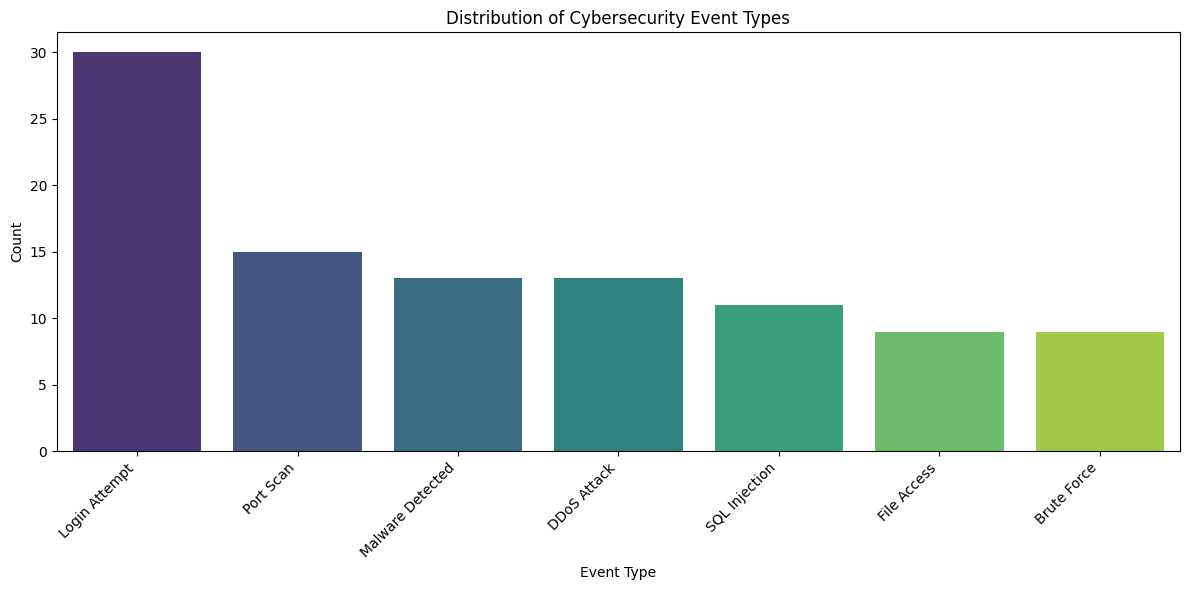

In [37]:
plt.figure(figsize=(12, 6))
sns.countplot(data=log_data, x='Event_Type', order=log_data['Event_Type'].value_counts().index, palette='viridis')
plt.title('Distribution of Cybersecurity Event Types')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_472/1116703990.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=log_data, x='Severity', order=['Low', 'Medium', 'High', 'Critical'], palette='magma')


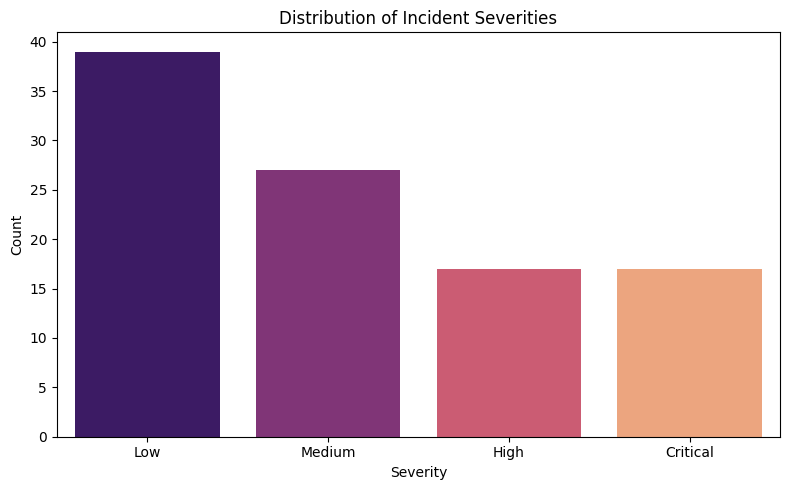

In [38]:
# Visualize Severity Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=log_data, x='Severity', order=['Low', 'Medium', 'High', 'Critical'], palette='magma')
plt.title('Distribution of Incident Severities')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()